# 1. Preparation

## 1.1 Prepare environment

In [34]:
# List all NVIDIA GPUs as available in this computer (or Colab's session)
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [35]:
!pip install torchinfo

In [36]:
import sys
print( f"Python {sys.version}\n" )

import random
import time

import numpy as np
print( f"NumPy {np.__version__}\n" )

import matplotlib.pyplot as plt
%matplotlib inline

import torchinfo
print( f"torchinfo {torchinfo.__version__}" )

# https://docs.pytorch.org/vision/0.21/transforms.html
import torchvision
print( f"torchvision {torchvision.__version__}" )
import torchvision.transforms.v2 as T

import torch
print( f"PyTorch {torch.__version__}" )

# Get all available accelerators such as CUDA, MPS, MTIA, or XPU
num_accelerators = torch.accelerator.device_count()

if (num_accelerators <= 0):
    print("|- No hardware accelerators found. Using CPU only.")
else:
    print(f"|- PyTorch detected {num_accelerators} hardware accelerator(s)")
    print(f"|- PyTorch detected '{torch.accelerator.current_accelerator().type.upper()}' as the current accelerator")

    # Check cuda availability
    if torch.cuda.is_available():
        num_gpus = torch.cuda.device_count()
        print(f"|- PyTorch detected {num_gpus} CUDA GPU(s):")

        # Important: The CUDA version in "nvidia-smi" must be equal or higher than "torch.version.cuda".
        # If they mismatch, it may cause silent hangs during heavy CUDA operations.
        # In that case, reinstall PyTorch from pytorch.org with the correct CUDA version.
        print(f"   |- {torch.version.cuda = }")
    for i in range(num_gpus):
        print(f"   |- CUDA GPU {i}: {torch.cuda.get_device_name(i)}")

Python 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]

NumPy 2.1.3

torchinfo 1.8.0
torchvision 0.26.0+cpu
PyTorch 2.11.0+cpu
|- No hardware accelerators found. Using CPU only.


In [37]:
# OpenCV library for image processing
import cv2 as cv

from PIL import Image
import requests
from io import BytesIO

## 1.2 Prepare global variables/functions

In [38]:
# Detect GPU (CUDA), Apple Silicon (MPS), or fallback to CPU
# 'device' is a scalar flag, not a tensor
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# 2. Prepare model and input image

## 2.1 Prepare the already-trained VGG-16 model

- Grad-CAM works with any trained CNN, whether custom-trained or pre-trained.
- For simplicity, this example uses torchvision's pre-trained VGG16 model.

In [39]:
weights = torchvision.models.VGG16_Weights.IMAGENET1K_V1
model = torchvision.models.vgg16(weights=weights).to(device).eval()

model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [40]:
torchinfo.summary( model )

Layer (type:depth-idx)                   Param #
VGG                                      --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       1,792
│    └─ReLU: 2-2                         --
│    └─Conv2d: 2-3                       36,928
│    └─ReLU: 2-4                         --
│    └─MaxPool2d: 2-5                    --
│    └─Conv2d: 2-6                       73,856
│    └─ReLU: 2-7                         --
│    └─Conv2d: 2-8                       147,584
│    └─ReLU: 2-9                         --
│    └─MaxPool2d: 2-10                   --
│    └─Conv2d: 2-11                      295,168
│    └─ReLU: 2-12                        --
│    └─Conv2d: 2-13                      590,080
│    └─ReLU: 2-14                        --
│    └─Conv2d: 2-15                      590,080
│    └─ReLU: 2-16                        --
│    └─MaxPool2d: 2-17                   --
│    └─Conv2d: 2-18                      1,180,160
│    └─ReLU: 2-19                

In [41]:
# Set the target layer for extracting activation maps
target_layer = model.features[-1]

target_layer

MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)

## 2.2 Prepare the input image

<class 'PIL.Image.Image'> (224, 224)


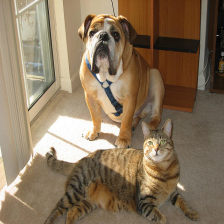

In [42]:
# Download an example image from Internet
url = "https://raw.githubusercontent.com/jacobgil/pytorch-grad-cam/master/examples/both.png"
response = requests.get(url)
orig_img = Image.open(BytesIO(response.content)).convert('RGB')

print( type(orig_img), orig_img.size )
orig_img

In [43]:
# Get the preprocessing that corresponds to the chosen version of VGG16
preprocess = weights.transforms()

preprocess

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [44]:
# Preprocess the input to match the model's requirement
# 'input_tensor' will be fed as an input image to the model
input_tensor = preprocess(orig_img).unsqueeze(0).to(device)

type(input_tensor), input_tensor.dtype, input_tensor.size(), input_tensor.min(), input_tensor.max()

(torch.Tensor,
 torch.float32,
 torch.Size([1, 3, 224, 224]),
 tensor(-1.8782),
 tensor(2.6400))

In [45]:
# Preprocess the input for GradCAM visualization
# 'rgb_img' will only be used for GradCAM visualization (with Matplotlib)
# 'rgb_img' will be used as an image background where GradCAM heatmap is overlaid on
input_size = preprocess.crop_size[0]  # Extract the required size from the 'preprocess'
rgb_img = np.float32(orig_img.resize((input_size, input_size))) / 255.0

type(rgb_img), rgb_img.dtype, rgb_img.shape, rgb_img.min(), rgb_img.max()

(numpy.ndarray,
 dtype('float32'),
 (224, 224, 3),
 np.float32(0.0),
 np.float32(1.0))

# 3. Three alternatives of GradCAM in PyTorch

## 3.1 Use the third-party library

In [46]:
!pip install grad-cam

In [47]:
# --- GRAD-CAM LIBRARY IMPORT ---
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
    HAS_GRAD_CAM_LIB = True
except ImportError:
    HAS_GRAD_CAM_LIB = False

print(f"{HAS_GRAD_CAM_LIB = }")

HAS_GRAD_CAM_LIB = True


In [48]:
def run_gradcam_library(model, target_layer, input_tensor, rgb_img, class_idx):
    """
    METHOD 1: Using the 'pytorch-grad-cam' library.
    Standard industry practice. Handles most CNNs automatically.
    """
    if not HAS_GRAD_CAM_LIB:
        return np.zeros_like(rgb_img)

    cam_lib = GradCAM(model=model, target_layers=[target_layer])
    targets = [ClassifierOutputTarget(class_idx)]
    mask = cam_lib(input_tensor=input_tensor, targets=targets)[0, :]

    return show_cam_on_image(rgb_img, mask, use_rgb=True)

## 3.2 Use the classic PyTorch's hook

In [49]:
class GradCAMHooks:
    """
    Classic implementation using PyTorch Hooks.
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Execute 'self.save_activation()' immediately after a forward function on the target layer completes
        self.fwd_handle = self.target_layer.register_forward_hook(self.save_activation)

        # Execute 'self.save_gradient()' during backpropagation when gradients are computed for the target layer
        self.bwd_handle = self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def remove_hooks(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

        self.activations = None
        self.gradients = None

    def compute(self, x, class_idx):
        '''This function computes the GradCAM heatmap
            for a given input image (x) and target class (class_idx).

            Only ONE input image can be passed as x.
        '''
        # Ensure that the model behaves in the eval mode
        self.model.eval()

        # Clear any leftover gradients from previous backward passes
        self.model.zero_grad()

        # Forward pass — this triggers save_activation() via the forward hook,
        # storing the target layer's feature maps in self.activations
        output = self.model(x)
        if (self.activations is None):
            print("[Method 2] Target_layer did not fire — check it's on the forward path")
            return

        # Select the raw (pre-softmax) logit for the class we want to explain
        logit = output[0, class_idx]

        # Backprop from this single scalar logit back through the network;
        # this triggers save_gradient() via the backward hook, storing
        # d(logit)/d(activations) in self.gradients
        logit.backward()

        # --- GradCAM computation ---

        # Global-average-pool the gradients over spatial dims (H, W) per channel.
        # This gives one importance weight per channel.
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)

        # Weighted sum of the activation maps across channels, using the
        # importance weights above — collapses [B, C, H, W] down to [B, H, W]
        cam = torch.sum(weights * self.activations, dim=1).squeeze(0)

        # Keep only positive influence (ReLU), since we only care about features
        # that *increase* the target class's score, not ones that suppress it;
        # detach from the graph and move to CPU/numpy for image processing
        cam = torch.relu(cam).detach().cpu().numpy()

        # Resize the (typically small, e.g. 7x7) CAM up to the input image's
        # spatial resolution so it can be overlaid as a heatmap
        cam = cv.resize(cam, (x.shape[3], x.shape[2]))

        # Min-max normalize to [0, 1] for visualization (heatmap coloring);
        # small epsilon avoids divide-by-zero if the CAM is completely flat
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam

In [50]:
def apply_heatmap(img, heatmap):
    """Blends a grayscale heatmap with an RGB image using OpenCV's JET colormap."""
    # Colorize the grayscale heatmap
    heatmap_color = cv.applyColorMap(np.uint8(255 * heatmap), cv.COLORMAP_JET)
    heatmap_color = np.float32(heatmap_color) / 255

    # Overlay the colorized heatmap on the original input image
    cam = heatmap_color + np.float32(img)
    cam = cam / np.max(cam)

    return np.uint8(255 * cam)

In [51]:
def run_gradcam_hooks(model, target_layer, input_tensor, rgb_img, class_idx):
    """METHOD 2 Wrapper: Computes CAM using manual forward/backward hooks."""
    cam_hooks = GradCAMHooks(model, target_layer)
    mask = cam_hooks.compute(input_tensor, class_idx)
    res = apply_heatmap(rgb_img, mask)

    return cv.cvtColor(res, cv.COLOR_BGR2RGB)  # Convert from BGR (OpenCV) to RGB

## 3.3 Use the modern FX-based extractor of PyTorch

In [52]:
from torchvision.models.feature_extraction import create_feature_extractor, get_graph_node_names

In [53]:
def find_node_name(model, target_module):
    """
    Helper: Converts a module OBJECT (like model.layer4[-1]) into its
    internal STRING name (like 'layer4.2.conv3').
    """
    for name, module in model.named_modules():
        if module is target_module:
            return name
    return None

In [54]:
def run_gradcam_feature_extractor(model, target_layer, input_tensor, rgb_img, class_idx):
    """
    METHOD 3: Using the modern 'create_feature_extractor' and 'retain_grad()'.
    """

    # --- 1. Resolve string names ---
    # 'create_feature_extractor' requires string "keys" to identify layers.
    # But we usually hold module objects. find_node_name() maps the object back to its key.
    target_node = find_node_name(model, target_layer)

    # --- 2. Find the graph end ---
    # Modern models (ResNet, etc.) aren't simple lists. We can't just use model[-1].
    # get_graph_node_names() flattens the execution logic (including skip connections).
    # 'eval_nodes[-1]' is the only reliable way to find where the final output is calculated.
    _, eval_nodes = get_graph_node_names(model)
    output_node = eval_nodes[-1]

    print(f"[Method 3] Resolved nodes: Target='{target_node}', Output='{output_node}'")

    # --- 3. Build a new GraphModule ---
    # The graph returns both the target features AND final prediction.
    # Extract target_node and output_node, giving as names `target_features` and `output`
    return_nodes = {target_node:'target_features' , output_node:'output' }
    new_model = create_feature_extractor(model, return_nodes=return_nodes)

    # --- 4. Forward pass ---
    out_dict = new_model(input_tensor)
    activations = out_dict['target_features']

    # --- 5. IMPORTANT! Call retain_grad() ---
    # By default, PyTorch deletes gradients for intermediate nodes to save memory.
    # retain_grad() tells PyTorch: "Keep these gradients so I can use them for Grad-CAM math."
    activations.retain_grad()

    # --- 6. Backward pass ---
    # Compute gradients relative to the target class
    logit = out_dict['output'][0, class_idx]
    logit.backward()

    # --- 7. GradCAM math ---
    # Access the gradients and perform the weighted combination
    grads = activations.grad
    weights = torch.mean(grads, dim=(2, 3), keepdim=True)
    mask = torch.sum(weights * activations, dim=1).squeeze()
    mask = torch.relu(mask).detach().cpu().numpy()

    # --- 8. Resize and min-max normalize for visualization ---
    mask = cv.resize(mask, (rgb_img.shape[1], rgb_img.shape[0]))
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)

    # --- 9. Return the colorized heatmap overlaid on the input image ---
    res = apply_heatmap(rgb_img, mask)
    return cv.cvtColor(res, cv.COLOR_BGR2RGB)

# 4. Run the three GradCAM methods

In [55]:
# Choose only the top 10 classes with highest prediction scores to visualize GradCAM
# GradCAM is NOT performed yet in this cell!

n_top = 10
with torch.inference_mode():
    outputs = model(input_tensor)
    probs = torch.nn.functional.softmax(outputs[0], dim=0)
    top_prob, top_catid = torch.topk(probs, n_top)

imagenet_classes = weights.meta["categories"]
for rank,i in enumerate( range(top_prob.size(0)) ):
    catid = top_catid[i].item()
    print(f"RANK {rank+1}: [{catid}] {imagenet_classes[catid]} ({top_prob[i].item() * 100:.2f}%)")

RANK 1: [254] pug (36.59%)
RANK 2: [243] bull mastiff (32.53%)
RANK 3: [242] boxer (9.43%)
RANK 4: [245] French bulldog (3.96%)
RANK 5: [282] tiger cat (1.36%)
RANK 6: [292] tiger (1.02%)
RANK 7: [180] American Staffordshire terrier (0.92%)
RANK 8: [247] Saint Bernard (0.80%)
RANK 9: [676] muzzle (0.78%)
RANK 10: [262] Brabancon griffon (0.76%)


In [56]:
# Visualize GradCAM heatmaps for the chosen classes

for rank_idx in range( n_top ):
    # Run the three GradCAM methods on the specific class_idx
    class_idx = top_catid[rank_idx]
    res1 = run_gradcam_library(model, target_layer, input_tensor, rgb_img, class_idx)
    res2 = run_gradcam_hooks(model, target_layer, input_tensor, rgb_img, class_idx)
    res3 = run_gradcam_feature_extractor(model, target_layer, input_tensor, rgb_img, class_idx)

    # Visualize the three results side-by-side
    fig, axes = plt.subplots(1, 4, figsize=(18, 6))
    fig.suptitle(f"[RANK {rank_idx+1}] Class {class_idx}: {imagenet_classes[class_idx]} ({top_prob[rank_idx].item() * 100:.2f}%)")
    subtitles = ["Original", "1. Library", "2. Hooks", "3. FX Extractor"]
    images = [rgb_img, res1, res2, res3]
    for i, (ax, img, title) in enumerate(zip(axes, images, subtitles)):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.